In [6]:
import xgboost
print(xgboost.__version__)

3.2.0


In [7]:
# Import models and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dictionary of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Display results
results_df = pd.DataFrame(results)

results_df.sort_values(by='ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
2,XGBoost,0.778252,0.589080,0.548128,0.567867,0.819670
1,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628


In [8]:
results_df.sort_values(by='ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
2,XGBoost,0.778252,0.589080,0.548128,0.567867,0.819670
1,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628


In [9]:
import joblib

joblib.dump(models['Logistic Regression'],
            '../models/churn_model.pkl')

['../models/churn_model.pkl']

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



<Figure size 600x500 with 0 Axes>

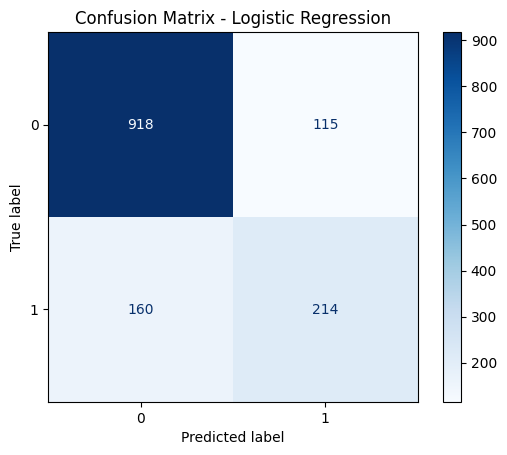

<Figure size 600x500 with 0 Axes>

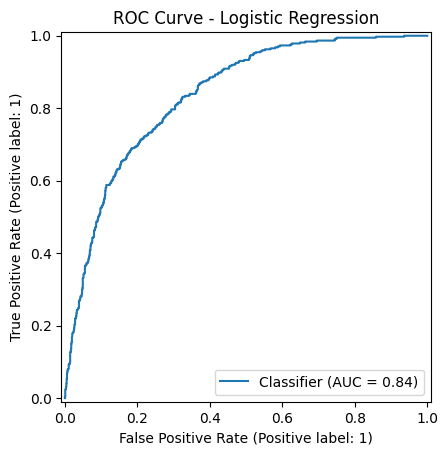

In [10]:
# Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Select the best model
best_model = models['Logistic Regression']

# Predictions
y_pred = best_model.predict(X_test)

# Prediction probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# -------------------------------
# Classification Report
# -------------------------------
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# -------------------------------
# ROC Curve
# -------------------------------
plt.figure(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [11]:
# Logistic Regression Feature Importance
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})

# Sort features
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

# Top 10 churn-increasing features
top_positive = coefficients.head(10)

# Top 10 churn-decreasing features
top_negative = coefficients.tail(10)

print("Top features increasing churn:")
display(top_positive)

print("\nTop features reducing churn:")
display(top_negative)

Top features increasing churn:


,Feature,Coefficient
10,InternetService_Fiber optic,1.121685
3,TotalCharges,0.641811
28,PaymentMethod_Electronic check,0.386286
21,StreamingTV_Yes,0.374880
9,MultipleLines_Yes,0.362680
23,StreamingMovies_Yes,0.347601
26,PaperlessBilling_Yes,0.290723
0,SeniorCitizen,0.195363
29,PaymentMethod_Mailed check,0.076969
17,DeviceProtection_Yes,0.073764



Top features reducing churn:


,Feature,Coefficient
12,OnlineSecurity_No internet service,-0.168056
8,MultipleLines_No phone service,-0.183234
6,Dependents_Yes,-0.231842
19,TechSupport_Yes,-0.329742
13,OnlineSecurity_Yes,-0.370820
2,MonthlyCharges,-0.445174
7,PhoneService_Yes,-0.522947
24,Contract_One year,-0.743489
25,Contract_Two year,-1.351225
1,tenure,-1.355817


In [12]:
import joblib

joblib.dump(best_model, '../models/churn_model.pkl')

print("Model saved successfully!")

Model saved successfully!
